Principais Gráficos Estatísticos para Análise de Dados

In [1]:
#importação da bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#importação dos dados e definição das variáveis

df = pd.read_csv("dados_prf.csv", encoding="latin1", sep=";")
df["acidente_fatal"] = (df["mortos"] > 0).astype(int)
fatal = df[df["acidente_fatal"] == 1]


In [3]:
#extra

tabela = fatal["mortos"].value_counts().sort_index().reset_index()
tabela.columns = ["mortos", "quantidade_acidentes"]
print(tabela)

tabela["percentual"] = (tabela["quantidade_acidentes"] / tabela["quantidade_acidentes"].sum() * 100).round(1)
print(tabela)

    mortos  quantidade_acidentes
0        1                  4632
1        2                   434
2        3                    93
3        4                    28
4        5                    13
5        6                     3
6        7                     2
7        9                     2
8       10                     1
9       11                     1
10      16                     1
    mortos  quantidade_acidentes  percentual
0        1                  4632        88.9
1        2                   434         8.3
2        3                    93         1.8
3        4                    28         0.5
4        5                    13         0.2
5        6                     3         0.1
6        7                     2         0.0
7        9                     2         0.0
8       10                     1         0.0
9       11                     1         0.0
10      16                     1         0.0


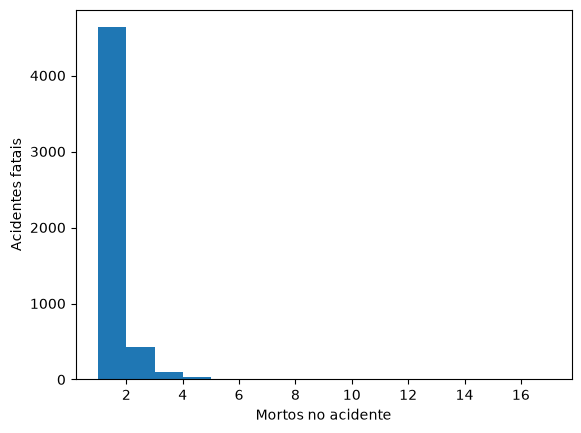

In [4]:
#histograma

plt.hist(fatal["mortos"], bins=range(1, fatal["mortos"].max()+2))
plt.xlabel("Mortos no acidente"); 
plt.ylabel("Acidentes fatais")
plt.show()

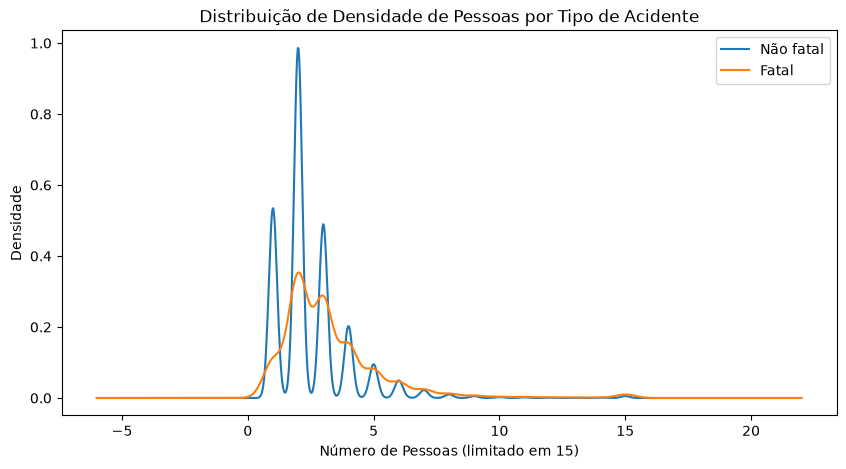

In [10]:
#gráfico de densidade

plt.figure(figsize=(10, 5))

for classe, nome in [(0, "Não fatal"), (1, "Fatal")]:
    dados = df.loc[df["acidente_fatal"] == classe, "pessoas"].dropna().clip(upper=15)
    dados.plot(kind="density", label=nome)

plt.title("Distribuição de Densidade de Pessoas por Tipo de Acidente")
plt.xlabel("Número de Pessoas (limitado em 15)")
plt.ylabel("Densidade")
plt.legend()
plt.show()


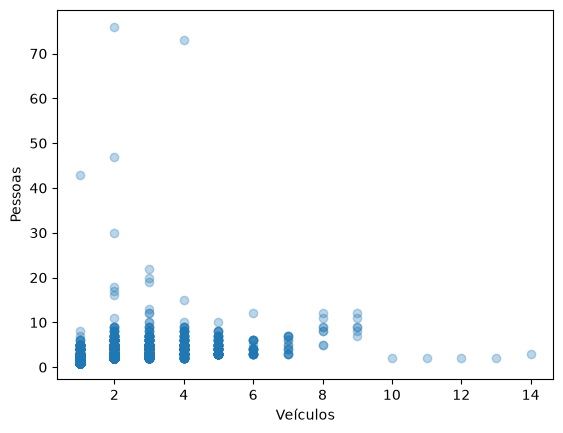

In [11]:
#grafico de dispersão

amostra = df.sample(5000, random_state=42)
plt.scatter(amostra["veiculos"], amostra["pessoas"], alpha=0.3)
plt.xlabel("Veículos"); 
plt.ylabel("Pessoas"); 
plt.show()


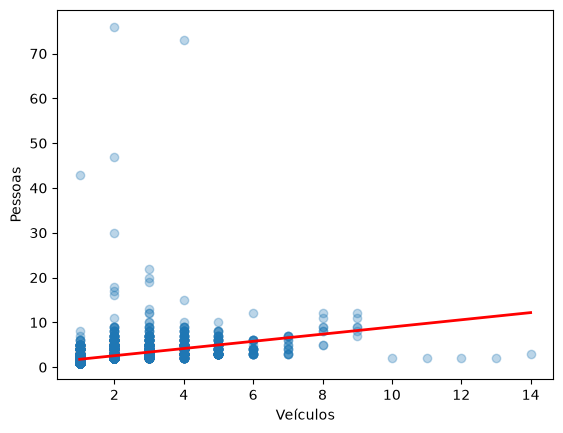

In [12]:
#extra

amostra = df.sample(5000, random_state=42)
plt.scatter(amostra["veiculos"], amostra["pessoas"], alpha=0.3)

b1, b0 = np.polyfit(amostra["veiculos"], amostra["pessoas"], 1)
x_linha = np.linspace(amostra["veiculos"].min(), amostra["veiculos"].max(), 100)
plt.plot(x_linha, b0 + b1 * x_linha, color="red", linewidth=2)

plt.xlabel("Veículos"); 
plt.ylabel("Pessoas"); 
plt.show()

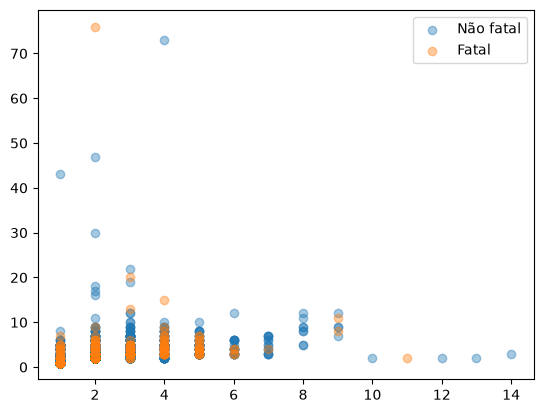

In [13]:
#dispersão com legendas

amostra = df.sample(5000, random_state=42)
for classe, nome in [(0,"Não fatal"),(1,"Fatal")]:
    g = amostra[amostra["acidente_fatal"] == classe]
    plt.scatter(g["veiculos"], g["pessoas"], alpha=0.4, label=nome)
plt.legend(); 
#plt.xlabel("..."); plt.ylabel("...")
plt.show()


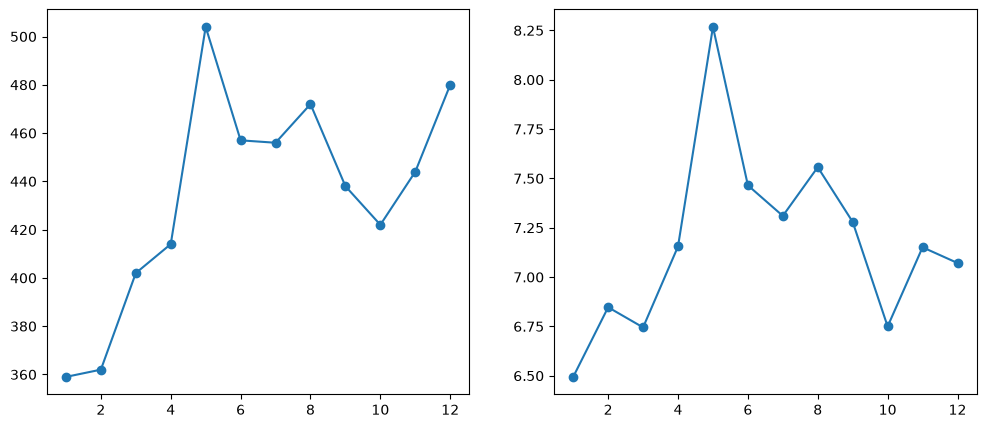

In [14]:
#divisão com legendas

df["data"] = pd.to_datetime(df["data_inversa"])
df["mes"] = df["data"].dt.month
df["acidente_fatal"] = (df["mortos"] > 0).astype(int)
m = df.groupby("mes").agg(acidentes=("id","count"), fatais=("acidente_fatal","sum"))
m["taxa"] = m["fatais"]/m["acidentes"]*100
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(m.index,m["fatais"],marker="o"); ax[1].plot(m.index,m["taxa"],marker="o")
#plt.xlabel("..."); plt.ylabel("...")
plt.show()


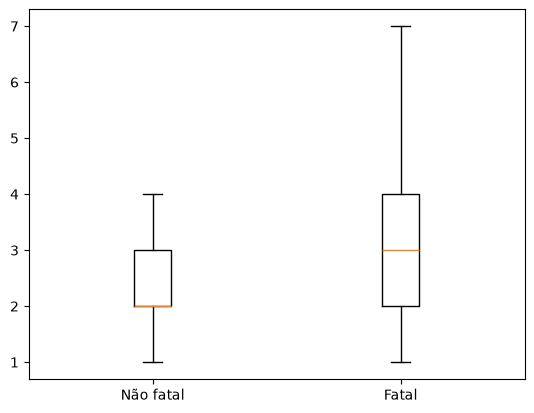

In [15]:
#boxplot

plt.boxplot([df.loc[df["acidente_fatal"]==0,"pessoas"],
             df.loc[df["acidente_fatal"]==1,"pessoas"]],
            tick_labels=["Não fatal","Fatal"], showfliers=False)
#plt.xlabel("..."); plt.ylabel("...")
plt.show()


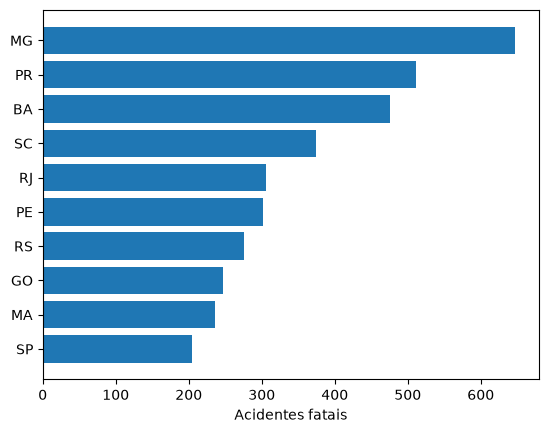

In [16]:
#gráfico de barras

uf = df.groupby("uf")["acidente_fatal"].sum().nlargest(10).sort_values()
plt.barh(uf.index, uf.values)
plt.xlabel("Acidentes fatais"); 
plt.show()


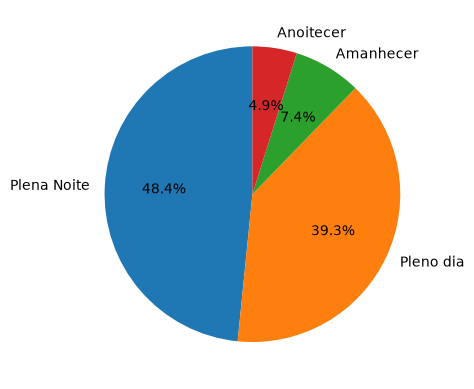

In [17]:
#gráfico de setores

fatal = df[df["acidente_fatal"]==1]
p = fatal["fase_dia"].value_counts()
plt.pie(p.values, labels=p.index, autopct="%1.1f%%", startangle=90)
plt.show()


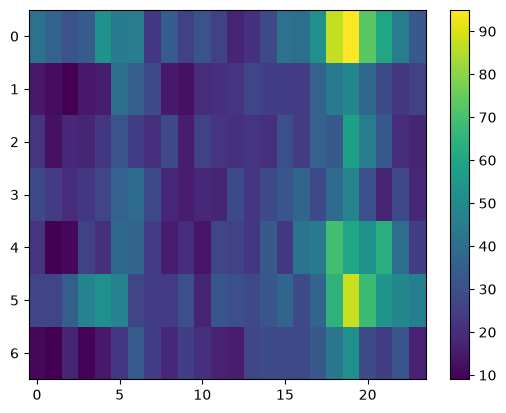

In [18]:
#Heatmap
df["hora_num"] = pd.to_datetime(df["horario"],format="%H:%M:%S").dt.hour
df["acidente_fatal"] = (df["mortos"] > 0).astype(int)
heat = pd.pivot_table(df,index="dia_semana",columns="hora_num",
                      values="acidente_fatal",aggfunc="sum",fill_value=0)
plt.imshow(heat.values,aspect="auto"); 
plt.colorbar(); 
#plt.xlabel("..."); plt.ylabel("...");
plt.show()


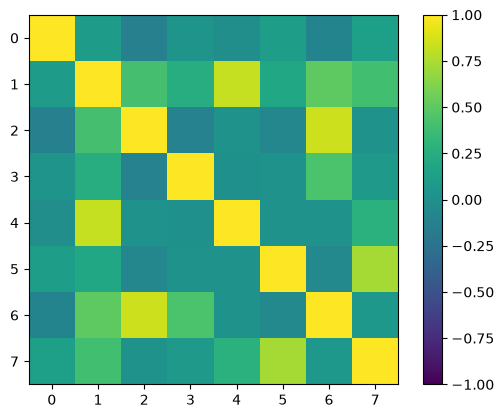

In [19]:
#extra - heatmap correlação

cols=["acidente_fatal","pessoas","feridos_leves","feridos_graves","ilesos","ignorados","feridos","veiculos"]
corr=df[cols].corr()
plt.imshow(corr.values,vmin=-1,vmax=1); 
plt.colorbar(); 
#plt.xlabel("..."); plt.ylabel("...");
plt.show()


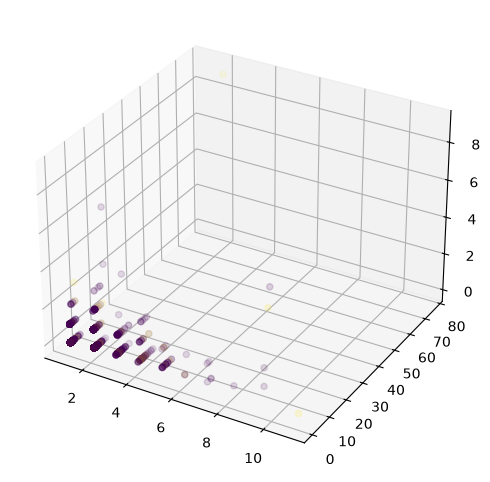

In [20]:
#gráfico 3D

s = df.sample(1500,random_state=42)
fig=plt.figure(figsize=(9,6)); ax=fig.add_subplot(111,projection="3d")
ax.scatter(s["veiculos"],s["pessoas"],s["feridos_graves"],c=s["acidente_fatal"],alpha=.4)
plt.show()


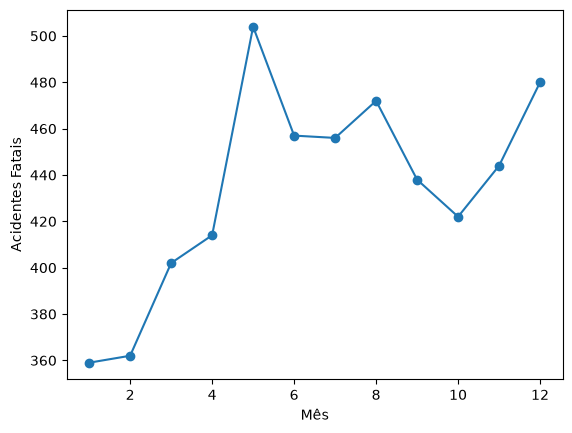

In [21]:
df["data"]=pd.to_datetime(df["data_inversa"])
df["mes"]=df["data"].dt.month
df["acidente_fatal"]=(df["mortos"]>0).astype(int)
mensal=df.groupby("mes")["acidente_fatal"].sum()
plt.plot(mensal.index,mensal.values,marker="o");
plt.xlabel("Mês"); 
plt.ylabel("Acidentes Fatais")
plt.show()


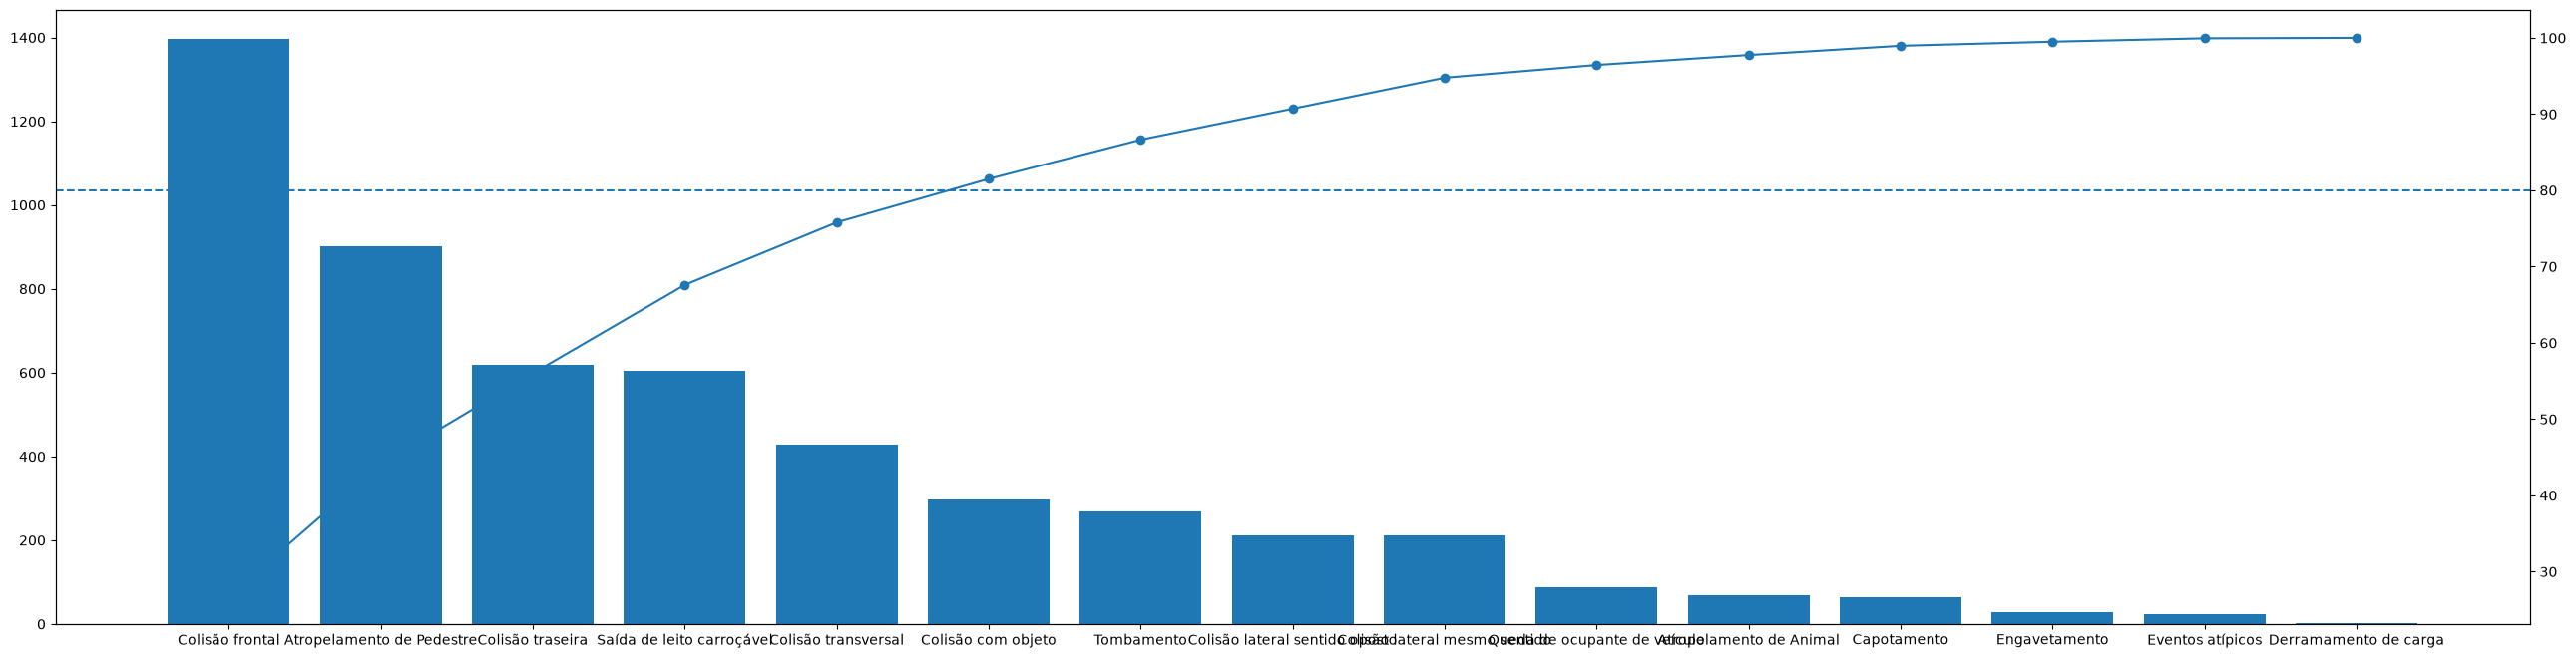

In [22]:
#gráfico de Pareto

df["acidente_fatal"]=(df["mortos"]>0).astype(int)
fatal=df[df["acidente_fatal"]==1]
p=fatal["tipo_acidente"].value_counts(); acum=p.cumsum()/p.sum()*100
fig,ax1=plt.subplots(figsize=(32,8)); ax1.bar(p.index,p.values)
ax2=ax1.twinx(); ax2.plot(p.index,acum.values,marker="o"); 
ax2.axhline(80,linestyle="--")
plt.xticks(rotation=45); 
plt.show()


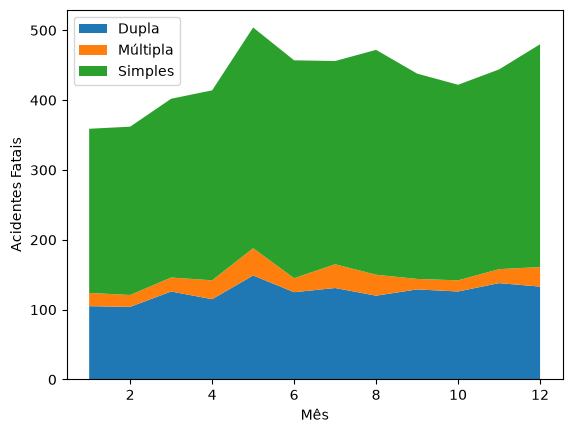

In [23]:
#gráfico de Área

df["data"]=pd.to_datetime(df["data_inversa"])
df["mes"]=df["data"].dt.month
df["acidente_fatal"]=(df["mortos"]>0).astype(int)
area=pd.pivot_table(df,index="mes",columns="tipo_pista",values="acidente_fatal",aggfunc="sum",fill_value=0)
plt.stackplot(area.index,*[area[c].values for c in area.columns],labels=area.columns)
plt.legend(); 
plt.xlabel("Mês"); 
plt.ylabel("Acidentes Fatais")
plt.show()


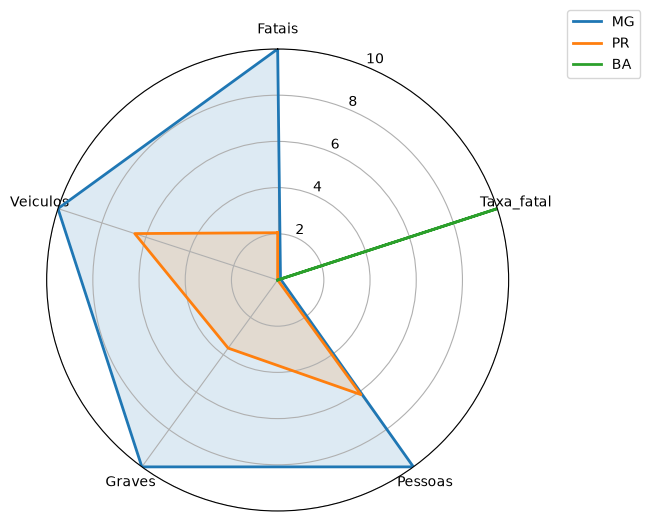

In [24]:
#gráfico Radar
agg=df.groupby("uf").agg(Acidentes=("id","count"),Fatais=("acidente_fatal","sum"),
    Pessoas=("pessoas","sum"),Graves=("feridos_graves","sum"),Veiculos=("veiculos","sum"))
agg["Taxa_fatal"]=agg["Fatais"]/agg["Acidentes"]*100
top=agg.nlargest(3,"Fatais")

metricas = ["Fatais", "Taxa_fatal", "Pessoas", "Graves", "Veiculos"]

# normaliza cada métrica para 0-10, com base no min/max entre as 3 UFs selecionadas
norm = (top[metricas] - top[metricas].min()) / (top[metricas].max() - top[metricas].min()) * 10

angulos = np.linspace(0, 2 * np.pi, len(metricas), endpoint=False).tolist()
angulos += angulos[:1]  # fecha o polígono

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(metricas)
ax.set_ylim(0, 10)

for uf in top.index:
    valores = norm.loc[uf].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, linewidth=2, label=uf)
    ax.fill(angulos, valores, alpha=0.15)

ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()